# ⚙️ Notebook 03 — Preprocessing
**Chicago Crime ML Pipeline**

Picks up the 3 engineered datasets from `02_feature_engineering.ipynb` and prepares them for model training:

| Step | What happens |
|---|---|
| Missing value imputation | Median for numerics, mode for categoricals |
| Outlier handling | IQR capping on skewed numeric features |
| Scaling | StandardScaler on all numeric features |
| Class imbalance | SMOTE oversampling for Task 1 & 2 |
| Train / Val / Test split | Stratified 70 / 15 / 15 |
| Save | Ready-to-train `.npz` + column metadata |

> **Next notebook:** `04_model_training.ipynb`

---
## 1. Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, json, joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# imbalanced-learn for SMOTE
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
    print('imbalanced-learn found ✅')
except ImportError:
    HAS_SMOTE = False
    print('⚠️  imbalanced-learn not installed. Run: pip install imbalanced-learn')
    print('   Falling back to class_weight="balanced" in models instead.')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR     = 'ml_data'
RANDOM_STATE = 42
TEST_SIZE    = 0.15
VAL_SIZE     = 0.15   # fraction of remaining train set

os.makedirs(DATA_DIR, exist_ok=True)
print('Config ready ✅')

imbalanced-learn found ✅
Config ready ✅


---
## 2. Load Engineered Datasets

In [2]:
# ⚡ Memory-optimised CSV loading — downcasts dtypes to cut RAM by ~60%
def load_csv_optimised(path):
    """Load CSV with automatic dtype downcast to minimise RAM usage."""
    df = pd.read_csv(path, low_memory=True)

    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')

    for col in df.select_dtypes(include=['object']).columns:
        if df[col].nunique() / len(df) < 0.5:   # low-cardinality → category
            df[col] = df[col].astype('category')

    mem_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f"  Loaded {path.split('/')[-1]}: {df.shape[0]:,} rows × {df.shape[1]} cols  |  RAM: {mem_mb:.1f} MB")
    return df


df1 = load_csv_optimised(f'{DATA_DIR}/task1_engineered.csv')
df2 = load_csv_optimised(f'{DATA_DIR}/task2_engineered.csv')
df3 = load_csv_optimised(f'{DATA_DIR}/task3_engineered.csv')

TARGETS = {
    'task1': 'ArrestInt',
    'task2': 'CrimeTypeEncoded',
    'task3': 'CrimeCount'
}

for name, df in [('Task 1', df1), ('Task 2', df2), ('Task 3', df3)]:
    nulls = df.isna().sum().sum()
    print(f'{name}: {df.shape[0]:,} rows × {df.shape[1]} cols  |  nulls: {nulls}')


  Loaded task1_engineered.csv: 247,054 rows × 24 cols  |  RAM: 12.3 MB
  Loaded task2_engineered.csv: 221,574 rows × 22 cols  |  RAM: 9.3 MB
  Loaded task3_engineered.csv: 119,140 rows × 20 cols  |  RAM: 5.8 MB
Task 1: 247,054 rows × 24 cols  |  nulls: 0
Task 2: 221,574 rows × 22 cols  |  nulls: 0
Task 3: 119,140 rows × 20 cols  |  nulls: 0


---
## 3. Preprocessing Utilities

In [3]:
# ⚡ Config guard — ensures variables are defined even if cells run out of order
DATA_DIR     = globals().get('DATA_DIR',     'ml_data')
RANDOM_STATE = globals().get('RANDOM_STATE', 42)
TEST_SIZE    = globals().get('TEST_SIZE',    0.15)
VAL_SIZE     = globals().get('VAL_SIZE',     0.15)
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except ImportError:
    HAS_SMOTE = False

def cap_outliers_iqr(df, cols, factor=3.0):
    """Cap extreme values beyond factor * IQR."""
    report = {}
    for col in cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - factor * iqr, q3 + factor * iqr
        n_capped = ((df[col] < lo) | (df[col] > hi)).sum()
        df[col] = df[col].clip(lo, hi)
        if n_capped:
            report[col] = n_capped
    return df, report


def preprocess_dataset(df, target_col, task_name,
                       task_type='classification'):
    
    """
    Full preprocessing pipeline for one task:
      1. Separate features / target
      2. Impute missing values
      3. Cap outliers
      4. Train / val / test split
      5. Scale
      6. SMOTE (classification only)
      7. Save artefacts
    """
    print(f"\n{'=' * 55}")
    print(f"  Processing {task_name}")
    print(f"{'=' * 55}")
    # ── 1. Split X / y ────────────────────────────────────────
    # ⚡ Cap rows to limit RAM during SMOTE / scaling
    MAX_ROWS = 120_000
    if len(df) > MAX_ROWS:
        df = df.sample(MAX_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)
        print(f'  ⚡ Sampled down to {MAX_ROWS:,} rows to save RAM')

    X = df.drop(columns=[target_col])
    y = df[target_col].values
    feature_names = list(X.columns)
    print(f'  Features : {len(feature_names)}   Target: {target_col}')

    # ── 2. Impute ─────────────────────────────────────────────
    # ⚡ Fix: cast bool & category dtypes so SimpleImputer doesn't crash
    for col in X.columns:
        if X[col].dtype == bool or str(X[col].dtype) == 'boolean':
            X[col] = X[col].astype('int8')
        elif hasattr(X[col], 'cat'):          # pandas category
            X[col] = X[col].astype(str)       # → object so imputer handles it

    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

    num_imputer = SimpleImputer(strategy='median')
    X[num_cols] = num_imputer.fit_transform(X[num_cols])

    if cat_cols:
        cat_imputer = SimpleImputer(strategy='most_frequent')
        X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])
        # Ordinal-encode any remaining string columns
        for col in cat_cols:
            X[col] = pd.Categorical(X[col]).codes

    X = X.astype(float)
    print(f'  Nulls after imputation : {X.isna().sum().sum()}')

    # ── 3. Outlier capping ────────────────────────────────────
    X, outlier_report = cap_outliers_iqr(X, num_cols)
    if outlier_report:
        print(f'  Outliers capped: {outlier_report}')
    else:
        print('  No extreme outliers detected')

    # ── 4. Train / Val / Test split ───────────────────────────
    strat = y if task_type == 'classification' else None
    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=strat
    )
    strat_val = y_train if task_type == 'classification' else None
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train,
        test_size=VAL_SIZE / (1 - TEST_SIZE),
        random_state=RANDOM_STATE, stratify=strat_val
    )
    print(f'  Split — train: {len(X_train):,}  val: {len(X_val):,}  test: {len(X_test):,}')

    # ── 5. Scale ──────────────────────────────────────────────
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    # ── 6. SMOTE (classification only) ───────────────────────
    if task_type == 'classification' and HAS_SMOTE:
        before = dict(zip(*np.unique(y_train, return_counts=True)))
        sm = SMOTE(random_state=RANDOM_STATE)
        X_train, y_train = sm.fit_resample(X_train, y_train)
        after = dict(zip(*np.unique(y_train, return_counts=True)))
        print(f'  SMOTE — before: {before}  →  after: {after}')
    elif task_type == 'classification':
        print('  SMOTE skipped (not installed) — use class_weight="balanced" in models')

    # ── 7. Save ───────────────────────────────────────────────
    npz_path = f'{DATA_DIR}/{task_name}_preprocessed.npz'
    np.savez_compressed(
        npz_path,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        X_test=X_test,   y_test=y_test
    )
    joblib.dump(scaler, f'{DATA_DIR}/{task_name}_scaler.pkl')

    meta = {
        'task_name'     : task_name,
        'task_type'     : task_type,
        'target_col'    : target_col,
        'feature_names' : feature_names,
        'n_features'    : len(feature_names),
        'train_size'    : int(len(X_train)),
        'val_size'      : int(len(X_val)),
        'test_size'     : int(len(X_test)),
        'smote_applied' : (task_type == 'classification' and HAS_SMOTE)
    }
    with open(f'{DATA_DIR}/{task_name}_meta.json', 'w') as f:
        json.dump(meta, f, indent=2)

    print(f'  ✅ Saved → {npz_path}')
    return X_train, X_val, X_test, y_train, y_val, y_test, scaler, meta


print('Preprocessing function defined ✅')

Preprocessing function defined ✅


---
## 4. Run Preprocessing — All 3 Tasks

In [4]:
results = {}

results['task1'] = preprocess_dataset(
    df1, target_col='ArrestInt', task_name='task1', task_type='classification'
)

results['task2'] = preprocess_dataset(
    df2, target_col='CrimeTypeEncoded', task_name='task2', task_type='classification'
)

results['task3'] = preprocess_dataset(
    df3, target_col='CrimeCount', task_name='task3', task_type='regression'
)

print('\n✅ All 3 tasks preprocessed!')


  Processing task1
  ⚡ Sampled down to 120,000 rows to save RAM
  Features : 23   Target: ArrestInt
  Nulls after imputation : 0
  Outliers capped: {'Domestic': 17372, 'Night_x_Weekend': 11255, 'Domestic_x_Night': 6012, 'Season_Spring': 27907, 'Season_Summer': 29923, 'Season_Winter': 26453}
  Split — train: 84,000  val: 18,000  test: 18,000
  SMOTE — before: {0: 42450, 1: 41550}  →  after: {0: 42450, 1: 42450}
  ✅ Saved → ml_data/task1_preprocessed.npz

  Processing task2
  ⚡ Sampled down to 120,000 rows to save RAM
  Features : 21   Target: CrimeTypeEncoded
  Nulls after imputation : 0
  Outliers capped: {'Domestic': 18993, 'Season_Spring': 28081, 'Season_Summer': 29709, 'Season_Winter': 26674, 'Night_x_Weekend': 10987}
  Split — train: 84,000  val: 18,000  test: 18,000
  SMOTE — before: {0: 5558, 1: 16672, 2: 4394, 3: 9024, 4: 4266, 5: 2974, 6: 3708, 7: 17207, 8: 3955, 9: 16242}  →  after: {0: 17207, 1: 17207, 2: 17207, 3: 17207, 4: 17207, 5: 17207, 6: 17207, 7: 17207, 8: 17207, 9: 

---
## 5. Visual Diagnostics

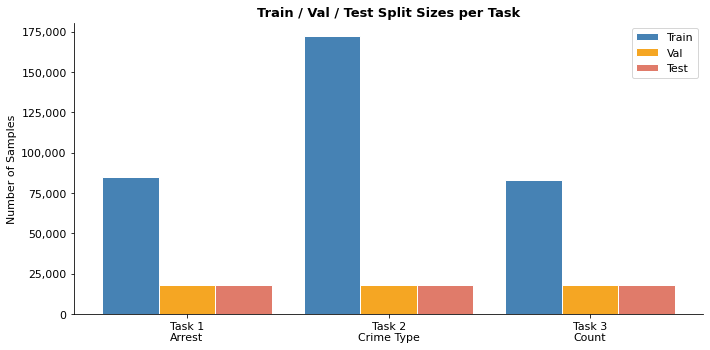

In [5]:
# ── Split size comparison ─────────────────────────────────────
task_labels = ['Task 1\nArrest', 'Task 2\nCrime Type', 'Task 3\nCount']
trains = [results[t][3].shape[0] for t in ['task1','task2','task3']]
vals   = [results[t][4].shape[0] for t in ['task1','task2','task3']]
tests  = [results[t][5].shape[0] for t in ['task1','task2','task3']]

x = np.arange(3)
w = 0.28
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, trains, width=w, label='Train', color='steelblue',   edgecolor='white')
ax.bar(x,     vals,   width=w, label='Val',   color='#f5a623',     edgecolor='white')
ax.bar(x + w, tests,  width=w, label='Test',  color='#e07b6a',     edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(task_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_title('Train / Val / Test Split Sizes per Task', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Samples')
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/03_split_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

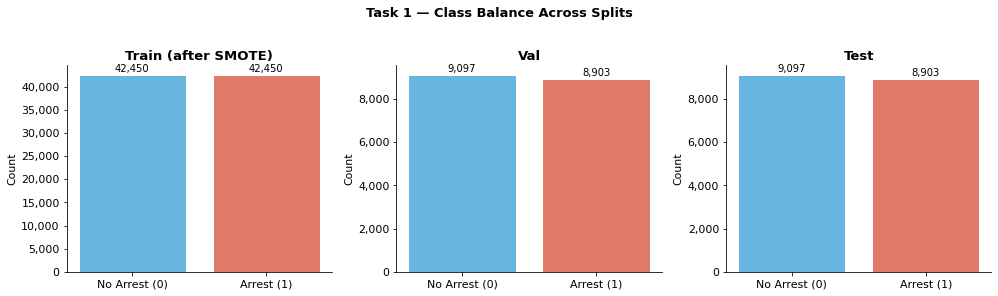

In [6]:
# ── Class balance before vs after SMOTE — Task 1 ─────────────
X_tr1, X_v1, X_te1, y_tr1, y_v1, y_te1, _, _ = results['task1']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sets = [('Train (after SMOTE)', y_tr1), ('Val', y_v1), ('Test', y_te1)]
colors_cls = ['#6ab4e0', '#e07b6a']

for ax, (title, y_set) in zip(axes, sets):
    vals_vc, counts = np.unique(y_set, return_counts=True)
    ax.bar(['No Arrest (0)', 'Arrest (1)'], counts, color=colors_cls, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    for i, c in enumerate(counts):
        ax.text(i, c + c * 0.02, f'{c:,}', ha='center', fontsize=10)

plt.suptitle('Task 1 — Class Balance Across Splits', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/03_class_balance_splits.png', dpi=150, bbox_inches='tight')
plt.show()

  Loaded task1_engineered.csv: 247,054 rows × 24 cols  |  RAM: 12.3 MB


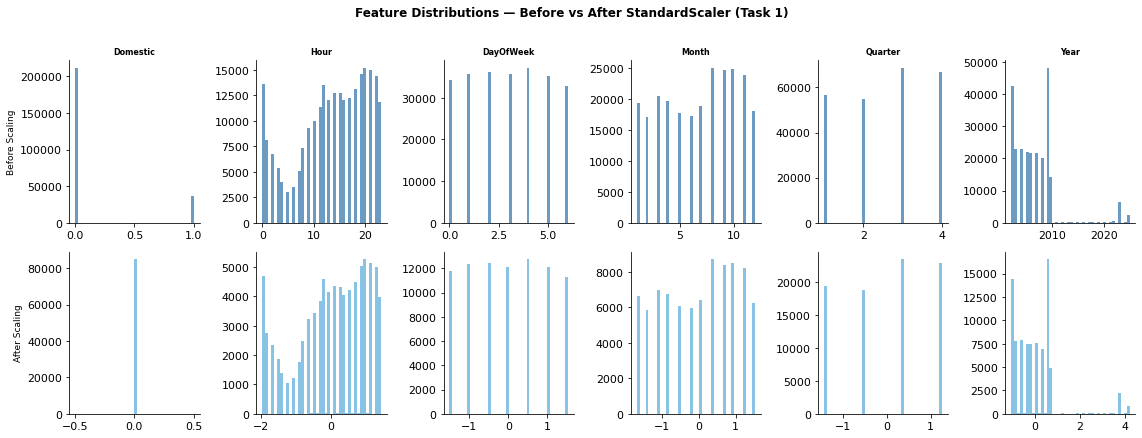

In [7]:
# ── Feature distribution before vs after scaling — Task 1 ─────
X_tr1_raw = load_csv_optimised(f'{DATA_DIR}/task1_engineered.csv').drop(columns=['ArrestInt'])  # ⚡ memory-safe
sample_cols = X_tr1_raw.select_dtypes(include=np.number).columns[:6].tolist()

fig, axes = plt.subplots(2, len(sample_cols), figsize=(16, 6))
for i, col in enumerate(sample_cols):
    # Before
    axes[0, i].hist(X_tr1_raw[col].dropna(), bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    axes[0, i].set_title(col, fontsize=8, fontweight='bold')
    if i == 0: axes[0, i].set_ylabel('Before Scaling', fontsize=9)
    # After
    axes[1, i].hist(X_tr1[:, i], bins=40, color='#6ab4e0', edgecolor='none', alpha=0.8)
    if i == 0: axes[1, i].set_ylabel('After Scaling', fontsize=9)

plt.suptitle('Feature Distributions — Before vs After StandardScaler (Task 1)',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/03_scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

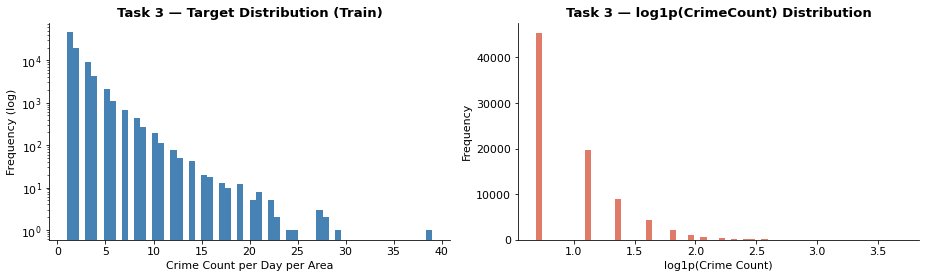

💡 Tip: Consider log-transforming CrimeCount before regression if RMSE is high.


In [8]:
# ── Task 3 target distribution (regression) ───────────────────
X_tr3, _, _, y_tr3, _, y_te3, _, _ = results['task3']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(y_tr3, bins=60, color='steelblue', edgecolor='none', log=True)
axes[0].set_title('Task 3 — Target Distribution (Train)', fontweight='bold')
axes[0].set_xlabel('Crime Count per Day per Area')
axes[0].set_ylabel('Frequency (log)')

axes[1].hist(np.log1p(y_tr3), bins=60, color='#e07b6a', edgecolor='none')
axes[1].set_title('Task 3 — log1p(CrimeCount) Distribution', fontweight='bold')
axes[1].set_xlabel('log1p(Crime Count)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/03_task3_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Tip: Consider log-transforming CrimeCount before regression if RMSE is high.')

---
## 6. Metadata Summary

In [9]:
print('=' * 65)
print('        NOTEBOOK 03 — PREPROCESSING COMPLETE')
print('=' * 65)
print(f'{"Task":<35} {"Train":>8} {"Val":>8} {"Test":>8} {"Features":>10}')
print('-' * 65)

task_info = [
    ('Task 1 — Arrest Prediction',   'task1'),
    ('Task 2 — Crime Type',          'task2'),
    ('Task 3 — Crime Count (Reg.)',  'task3'),
]

for label, key in task_info:
    with open(f'{DATA_DIR}/{key}_meta.json') as f:
        m = json.load(f)
    print(f'{label:<35} {m["train_size"]:>8,} {m["val_size"]:>8,} {m["test_size"]:>8,} {m["n_features"]:>10}')

print('=' * 65)
print()
print('  📁 Outputs saved to ml_data/:')
print('     task1_preprocessed.npz  |  task1_scaler.pkl  |  task1_meta.json')
print('     task2_preprocessed.npz  |  task2_scaler.pkl  |  task2_meta.json')
print('     task3_preprocessed.npz  |  task3_scaler.pkl  |  task3_meta.json')
print()
print('  ➡️  Next: 04_model_training.ipynb')
print('=' * 65)

        NOTEBOOK 03 — PREPROCESSING COMPLETE
Task                                   Train      Val     Test   Features
-----------------------------------------------------------------
Task 1 — Arrest Prediction            84,900   18,000   18,000         23
Task 2 — Crime Type                  172,070   18,000   18,000         21
Task 3 — Crime Count (Reg.)           83,398   17,871   17,871         19

  📁 Outputs saved to ml_data/:
     task1_preprocessed.npz  |  task1_scaler.pkl  |  task1_meta.json
     task2_preprocessed.npz  |  task2_scaler.pkl  |  task2_meta.json
     task3_preprocessed.npz  |  task3_scaler.pkl  |  task3_meta.json

  ➡️  Next: 04_model_training.ipynb
